In [1]:
from ruamel.yaml import YAML
import numpy as np

import torch

from transformers import BertTokenizerFast

from tqdm import tqdm

from MMDF_.models.HAMMER import HAMMER
from MMDF_.utils import text_input_adjust_inference, AttrDict, load_checkpoint

import numpy as np

import torch
import torch.nn.functional as F
from MMDF_.tools.multilabel_metrics import get_multi_label_inference

from MMDF_.models.HAMMER import HAMMER
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import cv2

c:\code\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
args= {
    "config": r"MMDF_\configs\test.yaml",
    "checkpoint": r"checkpoints\checkpoint_15.pth",
    "resume": False,
    "text_encoder": "bert-base-uncased",
    "device": "cuda",
}


args = AttrDict(args)
yaml = YAML(typ='safe') 

with open(args.config, 'r') as f:
    config = yaml.load(f)

In [3]:
device = torch.device(args.device)
#### Model #### 
tokenizer = BertTokenizerFast.from_pretrained(args.text_encoder)
model = HAMMER(args=args, config=config, text_encoder=args.text_encoder, tokenizer=tokenizer, init_deit=True)

model = model.to(device)   

# load model
load_checkpoint(args, model, None, None)

reshape position embedding from 196 to 256
_IncompatibleKeys(missing_keys=[], unexpected_keys=['head.weight', 'head.bias'])
<All keys matched successfully>


0

In [4]:
device = torch.device(args.device)
normalize = transforms.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
test_transform = transforms.Compose([
        transforms.Resize((config['image_res'],config['image_res']), interpolation=Image.BICUBIC),
        transforms.ToTensor(),
        normalize,
])
denormalize = transforms.Normalize(
    mean=[-0.48145466/0.26862954,
          -0.4578275/0.26130258,
          -0.40821073/0.27577711],
    std=[1/0.26862954,
         1/0.26130258,
         1/0.27577711]
)

In [5]:
image = Image.open('image.png')

In [6]:
image = Image.open('image.png')
text = "Famous streamer secretly joins a live-action Resident Evil project, accidentally leaking a disturbing ‘happy family’ photo from behind the scenes."

W, H = image.size
image = test_transform(image).to(device).unsqueeze(0)
text_input = tokenizer([text], max_length=128, truncation=True, add_special_tokens=True, return_attention_mask=True, return_token_type_ids=False)
text_input, _ = text_input_adjust_inference(text_input, device)

In [7]:
model.eval()
logits_real_fake, logits_multicls, output_coord, logits_tok = model(image, None, text_input, None, None, is_train=False)

In [16]:
torch.softmax(logits_real_fake, dim=-1)

tensor([[0.8411, 0.1589]], device='cuda:0', grad_fn=<SoftmaxBackward0>)

In [8]:
# BIC: real hay fake?
pred_label = logits_real_fake.argmax(dim=-1)  # 0=real, 1=fake

# MLC: loại fake nào?
pred_cls = torch.sigmoid(logits_multicls) > 0.5  # [B, 4] boolean

# IMG: bbox vùng bị chỉnh sửa (cx, cy, w, h) normalized
pred_bbox = output_coord  # [B, 4], giá trị 0~1

# TMG: token nào bị fake?
pred_tok = logits_tok.argmax(dim=-1)  # [B, seq_len], 1=fake token

In [9]:
get_multi_label_inference(pred_cls.squeeze(0).cpu())

'orig'

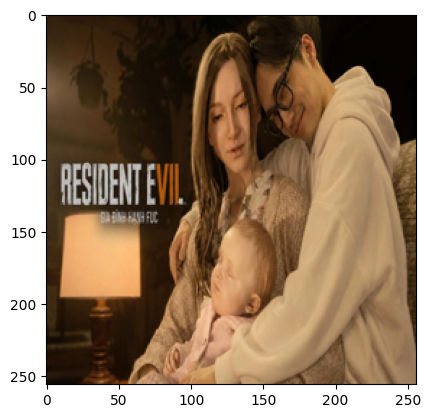

In [10]:
denorm_image = denormalize(image)
clip_image = denorm_image.clamp(0, 1)

H_, W_ = clip_image.shape[-2:] 

cx, cy, w, h = pred_bbox[0]
x1 = int((cx - w/2) * W_)
y1 = int((cy - h/2) * H_)
x2 = int((cx + w/2) * W_)
y2 = int((cy + h/2) * H_)


img = clip_image.squeeze(0).permute(1, 2, 0).cpu().numpy()
img = (img * 255).clip(0, 255).astype(np.uint8)
img = np.ascontiguousarray(img)

cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

plt.imshow(img)
plt.show()

In [11]:
tokens = tokenizer.convert_ids_to_tokens(text_input['input_ids'][0])
pred_tok = pred_tok[0]
pred_tok[10] = 1

In [12]:
tokens = tokens[1:-1]
for i, (token, tok) in enumerate(zip(tokens, pred_tok)):
    if tok == 1:
        tokens[i] = tokens[i].upper()
        
pred = tokenizer.convert_tokens_to_string(tokens)

In [13]:
words = []
for word_pred, word in zip(pred.split(), text.split()):
    if word_pred.isupper():
        words.append('<' + word + '>')
    else:
        words.append(word)

In [14]:
' '.join(words)

'Famous streamer secretly joins a live-action Resident Evil project, <accidentally> leaking a disturbing ‘happy family’ photo from behind the scenes.'